# **INF2008 Assignment 1 By Lab P3-1**
Team Members:
| Members | Student ID |
|---------|------------|
| Teng Tze Hui | 2502437 |
|Ee Chew Fong, Olivia | 2102743 |
| Gador Sophia Helen Santiago | 2503845 |
| Yap Yi Hui Wynn | 2501386 |

---

Dataset chosen: [Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset/data)

The dataset used in this project is **tabular data**, where each row represents an individual and each column corresponds to a specific demographic, health, or lifestyle attribute. The data does not contain any temporal component and is therefore **not time-series in nature**.

Dataset Notebooks:

While existing notebooks informed the general methodology, all code implementation, feature preparation, and analysis decisions in this notebook are **original unless otherwise stated**.

---

**Bob**, a **45-year-old office worker**, enjoys his job but often spends **long hours sitting** at his desk, skips **exercise**, and opts for **quick meals**. Recently, Bob was diagnosed with **hypertension**. One evening, while reading about **health risks**, he came across articles linking high blood pressure to strokes.
This made Bob anxious. He began to wonder: “Am I at **risk of having a stroke**? Should I see a doctor now?” Bob's concern is common among many people with **risk factors** who are unsure of their actual likelihood of developing serious health conditions.

**Problem Statement:** How can **health data** be analyzed to provide individuals with **clear, reliable insights** into their risk of stroke, enabling them to make **informed decisions** about seeking medical advice and adopting **preventive measures**?



# **Background Research**

**1. What is Stroke and How Does It Occur?**
- Normal brain function depends on a continuous supply of oxygen and nutrients delivered through blood vessels.
- A stroke occurs when blood flow to the brain is disrupted, leading to damage in the affected brain tissue and resulting in neurological signs and symptoms.

**2. How Common Is Stroke?**
- According to HealthHub Singapore, approximately **1 in 4 individuals** will experience a stroke in their lifetime.
- Stroke can occur across all age groups, genders, ethnicities, and socio-economic backgrounds, although the risk increases with age and certain health conditions.

**3. What Are the Different Types of Stroke?**

There are two main types of stroke:

1. **Ischaemic Stroke ("Blocked Artery")**

    - This is the most common type of stroke about **4 in 5 cases** and occurs when a blood clot obstructs an artery supplying blood to the brain. It is typically caused by:
      - **Thrombosis**: formation of a clot within a blood vessel supplying the brain
      - **Embolism**: a clot formed elsewhere in the body that travels to the brain

2. **Haemorrhagic Stroke ("Burst Artery")**

    - This type of stroke occurs when a blood vessel ruptures, causing bleeding within the brain happens in **1 in 5 cases**. Common causes include:
      - Chronic high blood pressure
      - Structural defects in blood vessels, such as **cerebral aneurysms**

Both types of stroke are **medical emergencies** and when stroke happens, **nearly two million brain cells die every minute** that a stroke is left untreated.

**Transient Ischaemic Attack (TIA)**  
In addition to the two main types, a transient ischaemic attack (TIA), or “mini-stroke,” involves a temporary interruption of blood flow to the brain. Symptoms resolve completely within a short time and do not result in permanent brain damage, but TIAs serve as an important warning sign for future stroke risk.

**4. Burden of Stroke in Singapore**
- Stroke is a **leading cause of long-term disability** in Singapore.

- Significant impact on **healthcare costs, caregivers, and workforce participation**.

- Early risk identification reduces hospitalisation and rehabilitation burden.

# **Import Libraries**

In [ ]:
# Import libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pprint import pprint

#kaggle dataset
import kagglehub

#sklearn preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# IMBlearn libraries
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# sklearn model evaluation
from sklearn import metrics

# sklearn classification models (subjected to changes)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Pickle library - Saving Models
import pickle

# Ignore warning
import warnings
warnings.filterwarnings("ignore")

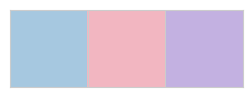

In [ ]:
# set background
sns.set_style('whitegrid')

# Custom colours
custom_palette = sns.color_palette([
    "#A6C8E0",  # soft blue
    "#F2B6C1",   # soft pink
    "#C3B1E1"  # soft lilac / purple
])

# set color palette
sns.set_palette(custom_palette)

# show the colour
sns.palplot(custom_palette)

# **Importing Dataset**

In [ ]:
# Download latest version
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'stroke-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/stroke-prediction-dataset


In [ ]:
# List the directory path
os.listdir(path)

['healthcare-dataset-stroke-data.csv']

In [ ]:
# Import dataset csv file as a dataframe
data = pd.read_csv(os.path.join(path, "healthcare-dataset-stroke-data.csv"))
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# **Data Exploration**
Explore the nature of the dataset can help us gain a better understanding of the characteristics of the dataset

This is a dataset collected from , it contains 5110 data points with 12 columns.


Attribute Information
| Attribute         | Data Type                        | Possible Values                                          | Role       |
| ----------------- | -------------------------------- | -------------------------------------------------------- | ---------- |
| id                | Categorical (numeric identifier) | Unique identifier                                        | Identifier |
| gender            | Categorical (nominal)            | Male, Female, Other                                      | Metadata   |
| age               | Numerical (continuous)           | Age in years                                             | Feature    |
| hypertension      | Categorical (binary)             | 0 = No, 1 = Yes                                          | Feature    |
| heart_disease     | Categorical (binary)             | 0 = No, 1 = Yes                                          | Feature    |
| ever_married      | Categorical (binary)             | Yes, No                                                  | Feature    |
| work_type         | Categorical (nominal)            | children, Govt_job, Never_worked, Private, Self-employed | Feature    |
| Residence_type    | Categorical (binary)             | Urban, Rural                                             | Feature    |
| avg_glucose_level | Numerical (continuous)           | Average glucose level                                    | Feature    |
| bmi               | Numerical (continuous)           | Body Mass Index                                          | Feature    |
| smoking_status    | Categorical (nominal)            | never smoked, formerly smoked, smokes, Unknown           | Feature    |
| stroke            | Categorical (binary, target)     | 0 = No stroke, 1 = Stroke                                | Target     |

*Note: "Unknown" in smoking_status means that the information is unavailable for this patient

Explanation of Roles:
- Identifier: Unique identifier for each entry (e.g., id).
- Metadata: Additional non-analysis related info (e.g., gender).
- Feature: Data used for analysis or prediction (e.g., age, hypertension).
- Target: The outcome variable you aim to predict (e.g., stroke in this case).

#### Descriptive Statstics

In [ ]:
#Make a copy to prevent mutation
stroke_ds = data.copy()

#Shape of dataset
print(stroke_ds.shape)

(5110, 12)


In [ ]:
stroke_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


**Observations**
- The dataset contains **5110 rows** and **12 columns**.
- There are **5 categorical features** (`object` type):  
  `gender`, `ever_married`, `work_type`, `Residence_type`, `smoking_status`.
- There are **3 continuous numerical features** (`float` type):  
  `age`, `avg_glucose_level`, `bmi`.
- There are **3 binary indicator variables** (`int` type):  
  `hypertension`, `heart_disease`, `stroke`.
- The `bmi` column contains **201 missing values**, while all other columns are complete.
- The `id` column serves as a unique identifier and does not contribute predictive value; it should be **removed before modeling** (after verifying uniqueness).
- The `stroke` column is the **target variable**, representing whether a stroke event occurred, making this a **binary classification problem**.



In [ ]:
# Descriptive Stats
stroke_ds.describe(include='all')

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


**Observations**
- The most frequent demographic groups are female, ever-married individuals, those working in the private sector, and urban residents.
- The mean age of individuals in the dataset is skewed towards middle to older adults.
- Hypertension and heart disease occur relatively infrequently, 9.7% and 5.4% respectively, suggest that most individuals do not have prior cardiovascular conditions.
- Average glucose level shows a wide range, with extreme high values, indicating a presence of potential outliers that may influence the results.
- Non - stroke cases account for about 95% of the dataset, indicating that the target variable stroke is highly imbalanced.

### Duplicated values

In [ ]:
# Check for duplicate rows
print(stroke_ds.duplicated().sum())

0


There are **no duplicated row**s in this dataset.

### Missing Values

In [ ]:
# Checking of null values in the dataset
stroke_ds.isnull().sum().sort_values()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
smoking_status,0


In [ ]:
# Check for "unknown" values for all columns
unknown_values = ["Unknown","unknown","NA","N/A","None","Other",""]
stroke_ds.isin(unknown_values).sum()

,0
id,0
gender,1
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


**Observations**
- The dataset is largely complete: **all columns have 0 missing values except `bmi`**, which contains **201 missing entries** (≈ **3.9%** of 5110 records).
- In addition to true nulls, there are **placeholder “unknown-like” values** in some categorical fields:
  - `smoking_status` contains **1544 entries** marked as `"Unknown"` (≈ **30.2%**), indicating substantial missingness recorded as a category rather than `NaN`.
  - `gender` contains **1 entry** flagged as an “unknown-like” value (rare, but should be checked/cleaned).
- These issues may affect model performance:
  - `bmi` missingness should be handled via **imputation** (e.g., median or model-based) to avoid losing rows.
  - `"Unknown"` in `smoking_status` should be treated as **informational missingness** (either keep as its own category or impute carefully), since dropping would remove a large portion of the dataset.


### Unique Values

In [ ]:
# Count number of distinct elements in specified axis.
stroke_ds.nunique().sort_values()

,0
hypertension,2
Residence_type,2
ever_married,2
heart_disease,2
stroke,2
gender,3
smoking_status,4
work_type,5
age,104
bmi,418


**Observations**
- Several variables have **two unique values**, indicating **binary features**:  
  `hypertension`, `heart_disease`, `ever_married`, `Residence_type`, and `stroke`.
- The `gender` variable has **three unique values**, suggesting the presence of an additional category beyond male and female (e.g., "Other"), which may require special handling during encoding.
- `smoking_status` contains **four distinct categories**, including an `"Unknown"` category, reinforcing the presence of categorical missingness.
- `work_type` has **five categories**, reflecting multiple employment types and requiring categorical encoding (e.g., one-hot encoding).
- Continuous numerical variables show high cardinality:
  - `age` has **104 unique values**, indicating a wide age range across individuals.
  - `bmi` has **418 unique values**, suggesting substantial variability and potential sensitivity to outliers.
  - `avg_glucose_level` has **3979 unique values**, indicating a near-continuous distribution.
- The `id` column has **5110 unique values**, matching the number of records, confirming that it is a **unique identifier** and should be excluded from predictive modeling.

# **Exploratory Data Analysis (EDA)**

In this section, we will visualize key features of the dataset to uncover insights.

#### **Data Visualizations:**
1. **Stroke Distribution**: Check for imbalanced data
2. **Age Distribution**: Visualizing the distribution of age across the dataset.
3. **Age Distribution vs. Stroke**: Analyzing how age is distributed between stroke and non-stroke cases.
4. **Gender vs. Stroke Comparison**: Comparing the incidence of stroke across genders.
5. **Marriage Status vs. Stroke**: Examining the relationship between marital status and stroke occurrence.
6. **Work Type vs. Stroke**: Investigating how different work types correlate with stroke risk.
7. **Residence Type vs. Stroke**: Analyzing stroke rates in urban vs. rural areas.
8. **Glucose Levels vs. Stroke**: Exploring the link between glucose levels and stroke incidence.
9. **Hypertension vs. Heart Disease vs. Stroke**: Using a heatmap to visualize the relationship between hypertension, heart disease, and stroke.
10. **Smoking Status**: Visualise the smoking status categories.


#### **Stroke Distribution**

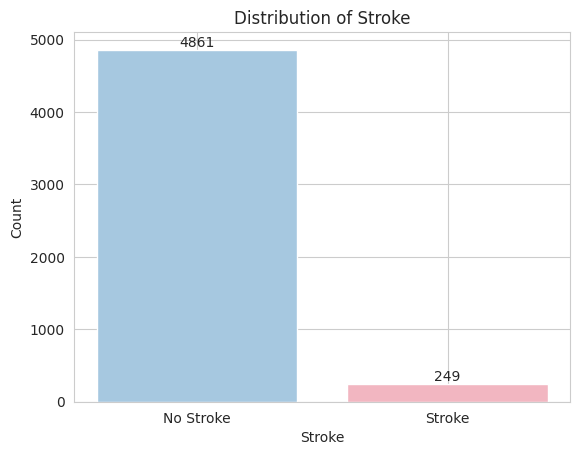

In [ ]:
# Count the number of people for each gender category
stroke = stroke_ds['stroke'].value_counts()

# Creating label for bar plot
x = ['No Stroke', 'Stroke']

# Create a bar plot
plt.bar(x, stroke.values, color = custom_palette)

# Add labels to the bars
for i, count in enumerate(stroke.values):
    plt.text(i, count, str(count), ha='center', va='bottom')

# Add labels and title
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Distribution of Stroke')

# Show the plot
plt.show()

**Observations:**
- The dataset is **highly imbalanced**, with the **"No Stroke"** class being significantly more prevalent than the **"Have Stroke"** class. Specifically:
  - There are **4,861** instances of **"No Stroke"**.
  - There are only **249** instances of **"Stroke"**.

- This imbalance may lead to the model being **biased toward predicting the majority class** (**"No Stroke"**), resulting in **poor performance** on the minority class (**"Stroke"**).

- The model could end up predicting **"No Stroke"** most of the time, leading to **suboptimal performance** when it comes to predicting the **minority class**.

- **Feature engineering** techniques will be necessary to balance the dataset and improve model performance on the minority class.

#### **Age Distribution**


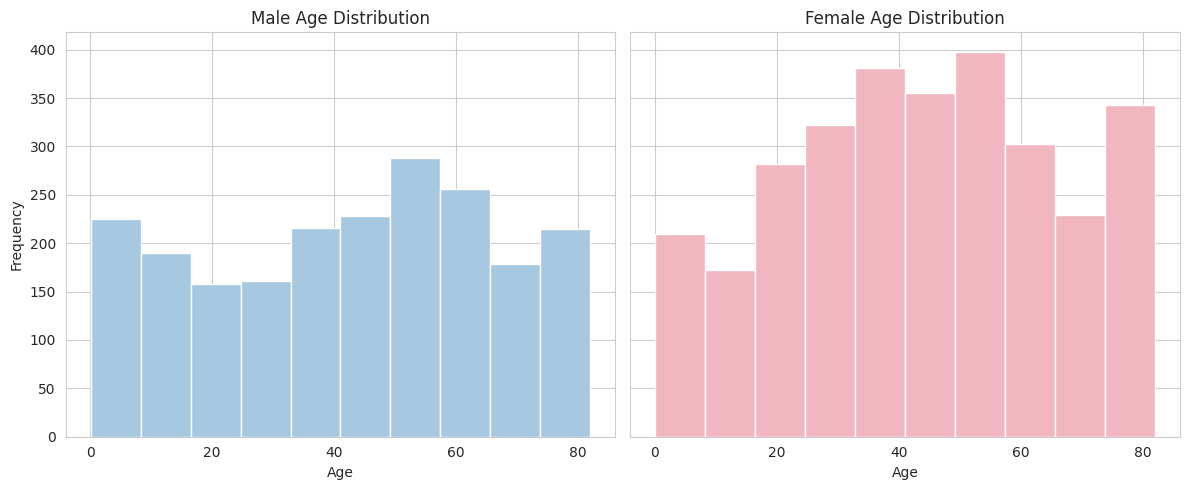

In [ ]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Male
axes[0].hist(stroke_ds[stroke_ds['gender'] == 'Male']['age'], bins=10, color=custom_palette[0])
axes[0].set_title('Male Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

# Female
axes[1].hist(stroke_ds[stroke_ds['gender'] == 'Female']['age'], bins=10, color=custom_palette[1])
axes[1].set_title('Female Age Distribution')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.show()

**Observations:**

- The age distributions for **male and female** individuals are **broadly similar**, spanning from childhood to older adulthood.
- Both genders show a **higher concentration in middle to older age ranges**, reflecting the overall age profile of the dataset.
- Female participants appear **slightly more represented** across most age bins, which is consistent with the higher overall number of female records in the dataset.
- No strong gender-specific age skew is observed, suggesting that **age is distributed comparably across genders** and should be considered independently of gender in subsequent analysis.

#### **Age Distribution vs Stroke**

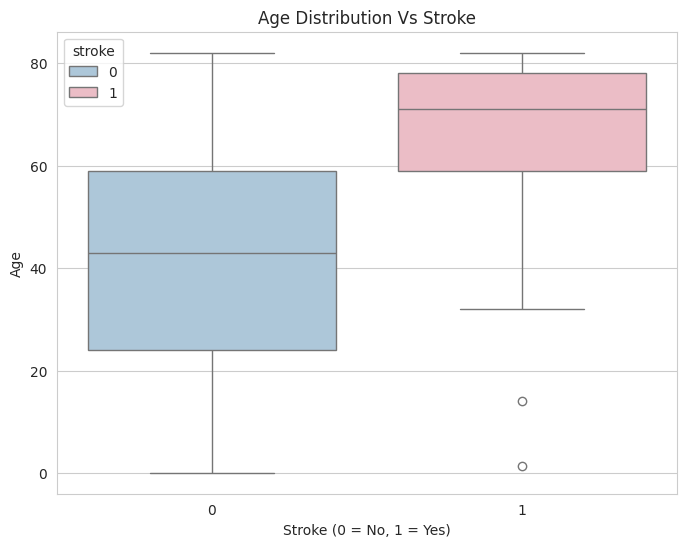

In [ ]:
# Box plot to compare age distribution between stroke & no - stroke group
plt.figure(figsize=(8, 6))

sns.boxplot(data=stroke_ds, x='stroke', y='age', hue='stroke')

plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.title('Age Distribution Vs Stroke')

plt.show()

**Observations**
- **Median age for stroke** cases is **higher** than that of no - stroke cases, indicating that **stroke** is **more common among older individuals**
- Interquartile range (IQR) for stroke cases is **concentratred** at **higher ages** (around 60 - 80)
- Most individuals under 40 years old fall in the no - stroke group, suggesting **low stroke risk at younger ages**
- **Outliers** at low ages in stroke group are **present**, implying that stroke can still occur in younger individuals

#### **Gender vs Stroke**

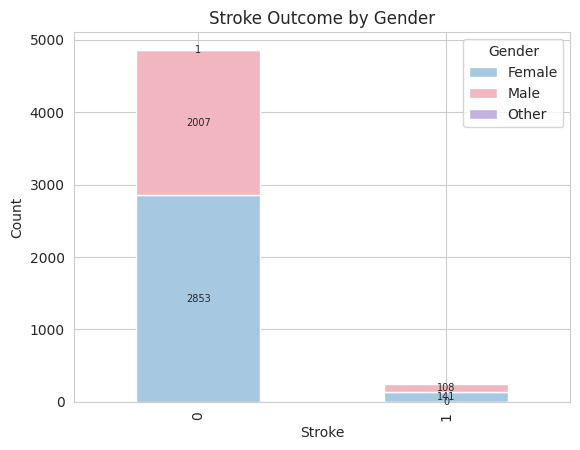

In [ ]:
# Create a cross-tabulation of stroke vs gender
stroke_gender = (
    stroke_ds
    .groupby(['stroke', 'gender'])
    .size()
    .unstack(fill_value=0)
)

ax = stroke_gender.plot(
    kind='bar',
    stacked=True,
    color=custom_palette
)

# Add number count
for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=7)


plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Stroke Outcome by Gender')
plt.legend(title='Gender')

plt.show()

**Observations**
- Indicates a **strong class imbalance** with significantly few stroke cases
- Stroke cases occur among both male and female individuals
- **Females** form the **larger population** in both stroke and no - stroke groups
  - **No stroke**: 2853 females, 2007 males, 1 other
  - **Stroke**: 141 females, 108 males, 0 other

While stroke cases are observed across both genders, this baseline analysis suggests that gender alone is insufficient to explain stroke risk, reinforcing the importance of clinical risk factors such as hypertension and metabolic health

#### **Marriage Status vs Stroke**


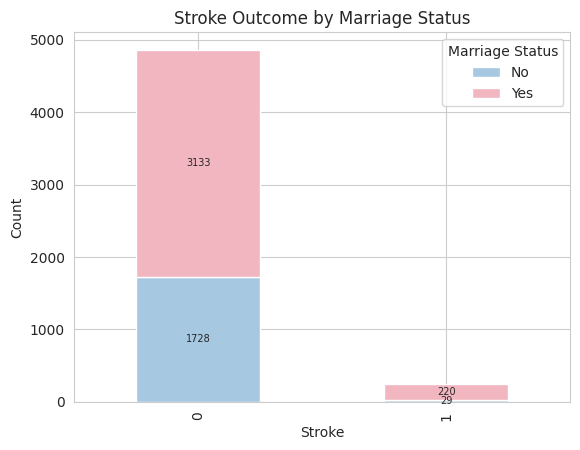

In [ ]:
# Create a cross-tabulation of stroke vs gender
stroke_marriage = (
    stroke_ds
    .groupby(['stroke', 'ever_married'])
    .size()
    .unstack(fill_value=0)
)

ax = stroke_marriage.plot(
    kind='bar',
    stacked=True,
    color=custom_palette
)

# Add number count
for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=7)


plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Stroke Outcome by Marriage Status')
plt.legend(title='Marriage Status')

plt.show()

**Observations:**

From the dataset, it appears that marital status may have a relationship with stroke occurrence. Out of the total individuals:
- **Married**: 3,133 had no stroke, while 220 experienced a stroke.
- **Not married**: 1,728 had no stroke, while only 29 experienced a stroke.

This suggests that the **majority** of stroke cases occurred among **married individuals**. While this does not imply causation, marital status may be a relevant factor to consider when analyzing stroke risk in this dataset.

#### **Work Type vs Stroke**


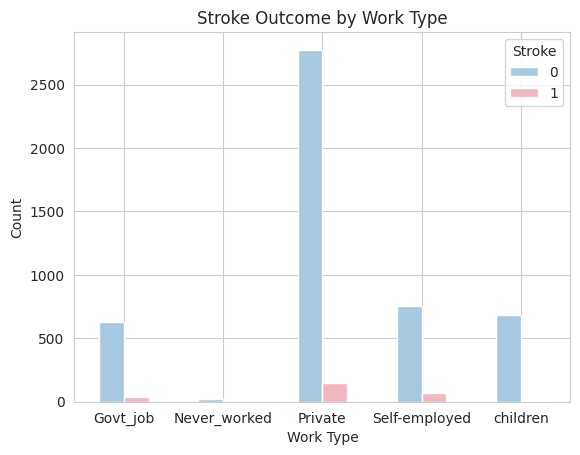

In [ ]:
# Work type vs Stroke
work_stroke = (
    stroke_ds
    .groupby(['work_type', 'stroke'])
    .size()
    .unstack(fill_value=0)
)

work_stroke.plot(kind='bar', color=custom_palette)

plt.xlabel('Work Type')
plt.ylabel('Count')
plt.title('Stroke Outcome by Work Type')
plt.legend(title='Stroke')
plt.xticks(rotation=0)
plt.show()

**Observations:**
- **Private employees** have the **highest stroke** and **no stroke cases**.
- **Self employed** individuals have **slight** presence in stroke cases
- **Government job** individuals have **even fewer** stroke cases which could indicate either lower risk or smaller representation in datset
- **Never worked** and **Children** have **no stroke** cases shown, likely due to small sample size and young age respectively

The graph alone does not provide a definitive assessment of stroke risk for an individual like Bob, but it highlights that work environment by itself is insufficient to predict stroke. While most individuals, regardless of work type, do not experience a stroke, certain work-related patterns such as sedentary office jobs may contribute indirectly to risk, particularly when combined with poor lifestyle habits.

#### **Residence Type vs Stroke**


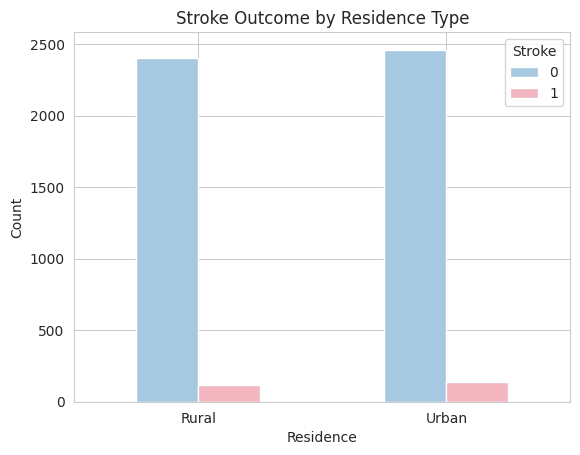

In [ ]:
# Residence type vs Stroke
residence_stroke = (
    stroke_ds
    .groupby(['Residence_type','stroke'])
    .size()
    .unstack()
)

residence_stroke.plot(kind='bar', color=custom_palette)

plt.xlabel('Residence')
plt.ylabel('Count')
plt.title('Stroke Outcome by Residence Type')
plt.legend(title='Stroke')
plt.xticks(rotation=0)
plt.show()

**Obseravtions:**
- **No stroke** : roughly **equal split** between rural and urban
- **Stroke** : **slightly more stroke** in urban areas than rural areas

Overall, `Residence_type` alone shows **limited separation** between stroke and non-stroke outcomes, so it is unlikely to be a strong standalone predictor without considering other risk factors (e.g., age, hypertension, glucose level).

#### **Glucose vs Stroke**


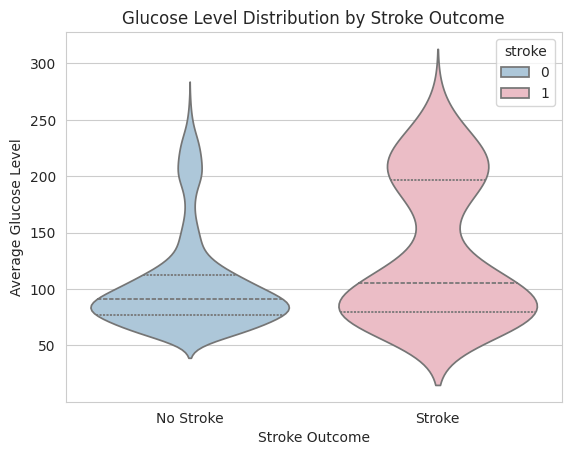

In [ ]:
# Glucose vs Stroke

plt.figure()
sns.violinplot(
    x='stroke',
    y='avg_glucose_level',
    data=stroke_ds,
    inner='quartile',
    hue='stroke'
)

plt.xticks([0, 1], ['No Stroke', 'Stroke'])
plt.xlabel('Stroke Outcome')
plt.ylabel('Average Glucose Level')
plt.title('Glucose Level Distribution by Stroke Outcome')
plt.show()


**Observations:**
- Stroke patients have a **higher median glucose level**, Individuals who experienced a stroke tend to have **higher average glucose levels** compared to those who did not experience a stroke.
- **High glucose levels are more common among stroke patients**, Elevated glucose levels occur more frequently among individuals with stroke.
- Stroke group shows **greater variability**, Glucose levels among stroke patients are more variable, suggesting that metabolic health differs widely within this group.
- Distributions overlap, There is **substantial overlap** between the two groups. Some non-stroke individuals have high glucose. Some stroke individuals have lower glucose.Although higher glucose levels are associated with stroke, **glucose level alone does not fully explain stroke occurrence**.

This analysis shows how health data can be used to provide clear and reliable insights into stroke risk by revealing **meaningful patterns rather than definitive diagnoses**. Individuals who experience stroke tend to have higher median glucose levels and greater variability, indicating an **association between metabolic health and stroke occurrence**.

However, the substantial overlap between stroke and non-stroke groups highlights that **glucose level alone is insufficient for accurate risk determination**. Instead, such data enables **probabilistic risk assessment**, helping individuals and healthcare providers recognise elevated risk signals, understand the limitations of single metrics, and make **informed decisions about preventive measures and medical consultation** by considering glucose levels alongside other factors such as hypertension, age, and lifestyle.



#### **Smoking Status**

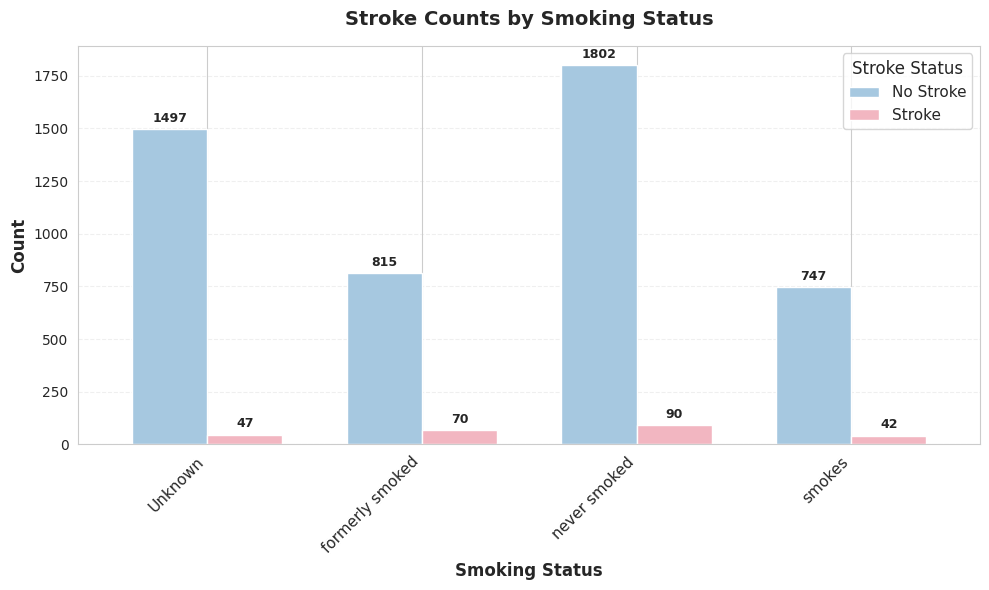

In [ ]:
# Create the crosstab
crosstab_data = pd.crosstab(stroke_ds['smoking_status'], stroke_ds['stroke'])

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
crosstab_data.plot(kind='bar', color=custom_palette[:2], ax=ax, width=0.7)

plt.xlabel('Smoking Status', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Stroke Counts by Smoking Status', fontsize=14, fontweight='bold', pad=15)

# Rotate x-axis labels (slanted)
plt.xticks(rotation=45, ha='right', fontsize=11)

# Update legend with meaningful labels
ax.legend(title='Stroke Status', labels=['No Stroke', 'Stroke'],
          loc='upper right', fontsize=11, title_fontsize=12)

# Add count and percentage labels on top of each bar
for container in ax.containers:
    # Get the total count for each smoking status group to calculate percentages
    labels = []
    for i, bar in enumerate(container):
        height = bar.get_height()
        if height > 0:
            # Get the x position to find which smoking status group we're in
            x_pos = int(bar.get_x() + bar.get_width() / 2)
        else:
            labels.append('')

    ax.bar_label(container, labels=labels, fontsize=9, fontweight='bold', padding=3)

# Add grid for better readability
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


**Observations:**
- Individuals who **formerly smoked exhibit the highest stroke percentage** compared to those who never smoked or currently smoke.
- Individuals with a **history of smoking show higher stroke risk** than those who never smoked, suggesting an **association between smoking exposure and stroke occurrence**.
- The relationship between smoking status and stroke risk is not strictly linear, indicating that factors such as **duration of exposure, age, or underlying health conditions** may influence observed stroke outcomes.

This analysis illustrates how health data can be leveraged to provide **clear and reliable insights into stroke risk** by uncovering **lifestyle-related patterns** rather than drawing deterministic conclusions. Individuals with a history of smoking, particularly former smokers, exhibit a **higher proportion of stroke cases** compared to those who never smoked, indicating an **association between smoking exposure and increased stroke risk**.

However, the **relationship is not strictly linear**, suggesting that additional factors such as duration of exposure, age, and underlying health conditions also play a role. By presenting stroke outcomes across smoking categories, the data helps individuals and healthcare providers recognise smoking history as a **meaningful risk signal** while also understanding its **limitations as a standalone predictor**.

This supports **informed decision-making** by encouraging **preventive measures**, such as smoking cessation and broader lifestyle modification, alongside clinical management to **reduce overall stroke risk**.



#### **Hypertension X Heart Disease -> Stroke Risk**

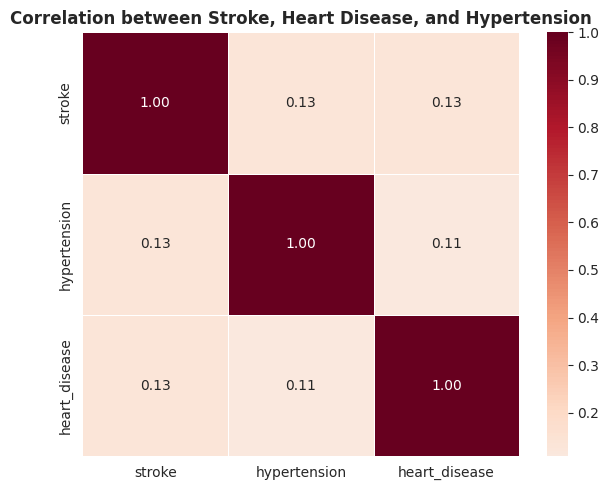

In [ ]:
# Select only relevant columns
cols_of_interest = ['stroke', 'hypertension', 'heart_disease']
df_subset = stroke_ds[cols_of_interest]

# Compute correlation matrix
corr_matrix = df_subset.corr()

# Plot heatmap
plt.figure(figsize=(6, 5), dpi=100)
sns.heatmap(
    corr_matrix,
    annot=True,         # show correlation values
    fmt=".2f",          # 2 decimal places
    cmap="RdBu_r",    # blue-red color map
    center=0,           # center color at 0
    linewidths=0.5
)

plt.title("Correlation between Stroke, Heart Disease, and Hypertension", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


**Observations:**

- Stroke shows **weak positive correlations** with both hypertension and heart disease (0.13).

- Hypertension and heart disease are weakly correlated with each other (0.11).

This suggests that **no single condition** has a strong linear relationship with stroke occurence, and stroke risk is likely influenced by **multiple interacting factors**.

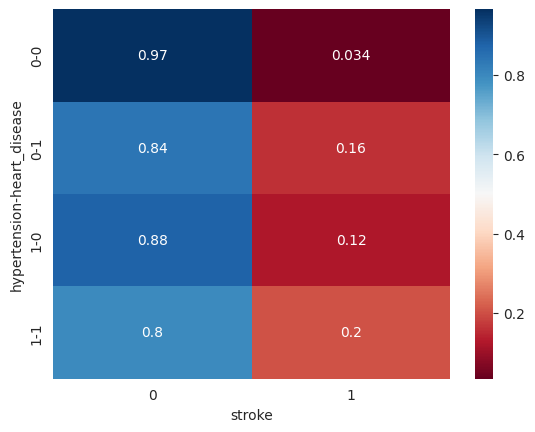

In [ ]:
# Combine the two medical conditions and compare against stroke outcome in a Cross-tabulation
combo = pd.crosstab([stroke_ds['hypertension'], stroke_ds['heart_disease']], stroke_ds['stroke'], normalize='index')

# Plot
sns.heatmap(combo, annot=True, cmap='RdBu')
plt.show()

**Additional Observations:**

`0-0`: No hypertension and no heart disease --> 97% no stroke, 3.4% have stroke

`0-1`: No hypertension but have heart disease --> 84% no stroke, 16% have stroke

`1-0`: With hypertension but no heart diease --> 88% no stroke, 12% have stroke

`1-1`: With both hypertension and heart disease --> 80% no stroke, 20% have stroke

- This shows that stroke risk increases as **more medical conditions** are present, and combined conditions substantially increase the risk.
- Having **either one** condition does increase the risk by a significant amount (12-16%) compared to having none (3%).
- Having **both** conditions gives the highest stroke proportion (20%).

While the correlation heatmap shows weak linear relationships, the cross-tabulation reveal that hypertension and heart disease have a **meaningful combined impact** on stroke risk, highlighting interaction effects not captured by correlation coefficients.




# **Data Cleaning**
- **Drop unwanted values**
  - ID, Gender, Work type
- **Handing Missing Values**
- **Binary Encoding**

### **Drop Unwanted Values**

#### **ID**
Since id is just an identifier and not a relevant attribute to the target, the column can be dropped

In [ ]:
# drop id column
stroke_ds = stroke_ds.drop(columns=["id"])

#### **Gender**
Since there is only one row with "Other" gender, its removal has a negligible impact on the overall data distribution and model performance.

In [ ]:
# handling unknown values in gender

# Count how many times each gender value appears in the dataset
gender_count = stroke_ds['gender'].value_counts()

# Extract the unique gender values present in the dataset
unique_gender = gender_count.index

# Display the frequency of each gender value
print("Value counts in D:\n", gender_count)

# Display the unique gender categories found
print("Unique values in D:", list(unique_gender))

Value counts in D:
 gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64
Unique values in D: ['Female', 'Male', 'Other']


In [ ]:
# find the row with "other" as gender
stroke_ds[stroke_ds["gender"].isin(unknown_values)]

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3116,Other,26.0,0,0,No,Private,Rural,143.33,22.4,formerly smoked,0


In [ ]:
# drop
stroke_ds.drop(index=3116, inplace=True)

In [ ]:
# verify
gender_count = stroke_ds['gender'].value_counts()
unique_gender = gender_count.index
print("Value counts in D:\n", gender_count)
print("Unique values in D:", list(unique_gender))

Value counts in D:
 gender
Female    2994
Male      2115
Name: count, dtype: int64
Unique values in D: ['Female', 'Male']


In [ ]:
stroke_ds.iloc[3116]

,3117
gender,Female
age,9.0
hypertension,0
heart_disease,0
ever_married,No
work_type,children
Residence_type,Rural
avg_glucose_level,80.55
bmi,15.1
smoking_status,Unknown


#### **Work Type**

Based on the exploratory data analysis (EDA), we observed that the 'children' category in the work_type column is irrelevant to our analysis. Since we are focused on working adults, this category does not contribute meaningful information. Therefore, we will remove the 'children' entries from the dataset.

In [ ]:
# Drop rows where the 'work_type' is 'children' from the dataset
stroke_ds = stroke_ds[stroke_ds['work_type'] != 'children']

In [ ]:
# new data shape
print(stroke_ds.shape)

(4422, 11)


### **Handle Missing Values**

#### **BMI**

Since bmi is a numerical value, the missing values can be handled by imputing using median by age.


In [ ]:
# count the missing values
stroke_ds["bmi"].isnull().sum()

np.int64(185)

In [ ]:
group_median = stroke_ds.groupby("age")["bmi"].transform("median") # group by age
global_median = stroke_ds["bmi"].median() # get the median

# create a new column bmi_imputed
stroke_ds["bmi_imputed"] = (
    stroke_ds["bmi"]
    .fillna(group_median)
    .fillna(global_median)
)

In [ ]:
# show the dataset after imputed
stroke_ds.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_imputed
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,36.60
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1,29.45
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,32.50
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,34.40
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,24.00


In [ ]:
# check for missing values again
stroke_ds["bmi_imputed"].isnull().sum()

np.int64(0)

In [ ]:
# To maintain a clean dataset, we replace the original bmi column with bmi_imputed column.
stroke_ds = stroke_ds.drop(columns=["bmi"])

In [ ]:
# show the new dataset
stroke_ds.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,smoking_status,stroke,bmi_imputed
0,Male,67.0,0,1,Yes,Private,Urban,228.69,formerly smoked,1,36.60
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,never smoked,1,29.45
2,Male,80.0,0,1,Yes,Private,Rural,105.92,never smoked,1,32.50
3,Female,49.0,0,0,Yes,Private,Urban,171.23,smokes,1,34.40
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,never smoked,1,24.00


#### **Smoking Status**

The dataset contains 1544 rows with "Unknown" as the smoking_status. This is about 30% of the entire dataset, so dropping them would remove too much data and significantly reduce sample size.

“Unknown” still carries information and is still potentially useful for stroke prediction. The feature was retained as smoking is a clinically relevant risk factor. “Unknown” was treated as a separate category to preserve data and avoid introducing bias through incorrect imputation.

In [ ]:
# Count the occurrences of each unique value in the 'smoking_status' column to understand the distribution of smokers in the dataset
smoker_count = stroke_ds['smoking_status'].value_counts()

# Extract the unique smoker status values (index) from the smoker_count series to see which statuses are represented in the dataset
unique_smoker = smoker_count.index

# Print the count of each status in the 'smoking_status' column to visualize the distribution of status
print("Value counts in D:\n", smoker_count)

# Print the unique values in the 'smoking_status' column to see which categories are present
print("\nUnique values in D:", list(unique_smoker))

Value counts in D:
 smoking_status
never smoked       1838
Unknown             926
formerly smoked     871
smokes              787
Name: count, dtype: int64

Unique values in D: ['never smoked', 'Unknown', 'formerly smoked', 'smokes']


### **Binary Encoding**

#### **Gender**
In this section, we examine the `gender` column to understand its distribution and prepare it for downstream modelling.

1. **Distribution Analysis**:  
   The frequency of each gender category (`Male`, `Female`) is computed using value counts to understand the representation of genders in the dataset. This provides basic contextual information about the dataset composition but does not imply any relationship with stroke outcomes.

2. **Binary Encoding**:  
   The `gender` column is converted from categorical values (`Male`, `Female`) to numerical values (**1 for Male, 0 for Female**). This transformation is required because machine learning models operate on numerical inputs. As `gender` is binary, label encoding is sufficient and avoids unnecessary one-hot expansion.

This encoded feature is then used directly in the modelling pipeline as a numerical variable.


**BEFORE**

In [ ]:
# Count the occurrences of each unique value in the 'gender' column to understand the distribution of genders in the dataset
gender_count = stroke_ds['gender'].value_counts()

# Extract the unique gender values (index) from the gender_count series to see which genders are represented in the dataset
unique_gender = gender_count.index

# Print the count of each gender in the 'gender' column to visualize the distribution of genders
print("Value counts in D:\n", gender_count)

# Print the unique gender values in the 'gender' column to see which categories (e.g., Male, Female) are present
print("\nUnique values in D:", list(unique_gender))

Value counts in D:
 gender
Female    2668
Male      1754
Name: count, dtype: int64

Unique values in D: ['Female', 'Male']


**AFTER**

In [ ]:
# Convert the 'gender' column from categorical values ('Male'/'Female') to numerical values (1 for 'Male', 0 for 'Female')
stroke_ds["gender"] = stroke_ds["gender"].map({"Male": 1, "Female": 0})

# Count the occurrences of each unique value in the 'gender' column to understand the distribution of genders in the dataset
gender_count = stroke_ds['gender'].value_counts()

# Extract the unique gender values (index) from the gender_count series to see which genders are represented in the dataset
unique_gender = gender_count.index

# Print the count of each gender in the 'gender' column to visualize the distribution of genders
print("Value counts in D:\n", gender_count)

# Print the unique gender values in the 'gender' column to see which categories (e.g., Male, Female) are present
print("\nUnique values in D:", list(unique_gender))

Value counts in D:
 gender
0    2668
1    1754
Name: count, dtype: int64

Unique values in D: [0, 1]


#### **Ever Married**

In this section, we examine the `ever_married` column to understand the distribution of marital status and prepare the feature for modelling.

1. **Distribution Analysis**:  
   The frequency of each category (`Yes`, `No`) is computed to describe the proportion of individuals who have ever been married versus those who have not. This provides contextual information about the dataset composition without implying any relationship with stroke outcomes.

2. **Binary Encoding**:  
   The `ever_married` column is converted from categorical values (`Yes`, `No`) to numerical values (**1 for Yes, 0 for No**). This transformation is required because machine learning models operate on numerical inputs. As the feature is binary, label encoding is sufficient and avoids unnecessary feature expansion.

The encoded feature is subsequently used as a numerical input in the modelling pipeline.


**BEFORE**

In [ ]:
# Count the occurrences of each unique value in the 'ever_married' column
marriage_count = stroke_ds['ever_married'].value_counts()

# Get the unique values (index) from the marriage count
unique_marriage = marriage_count.index

# Print the count of each value in 'ever_married' column
print("Value counts in D:\n", marriage_count)

# Print the unique values in 'ever_married' column
print("\nUnique values in D:", list(unique_marriage))

Value counts in D:
 ever_married
Yes    3353
No     1069
Name: count, dtype: int64

Unique values in D: ['Yes', 'No']


**AFTER**

In [ ]:
# Convert 'Yes' to 1 and 'No' to 0 in the 'ever_married' column using the map function
stroke_ds["ever_married"] = stroke_ds["ever_married"].map({"Yes": 1, "No": 0})

# Count the occurrences of each unique value in the 'ever_married' column (1 for Yes, 0 for No)
marriage_count = stroke_ds['ever_married'].value_counts()

# Get the unique values (index) from the marriage count
unique_marriage = marriage_count.index

# Print the count of each value in 'ever_married' column
print("Value counts in D:\n", marriage_count)

# Print the unique values in 'ever_married' column
print("\nUnique values in D:", list(unique_marriage))

Value counts in D:
 ever_married
1    3353
0    1069
Name: count, dtype: int64

Unique values in D: [1, 0]


#### **Residence Type**

In this section, we examine the `Residence_type` column to understand the distribution of residential areas and prepare the feature for modelling.

1. **Distribution Analysis**:  
   The frequency of each category (`Urban`, `Rural`) is computed to describe the proportion of individuals living in urban versus rural areas. This provides contextual information about the dataset composition without implying any relationship with stroke outcomes.

2. **Binary Encoding**:  
   The `Residence_type` column is converted from categorical values (`Urban`, `Rural`) to numerical values (**1 for Urban, 0 for Rural**). This transformation is required because machine learning models operate on numerical inputs. As the feature is binary, label encoding is sufficient and avoids unnecessary feature expansion.

The encoded feature is then used directly as a numerical input in the modelling pipeline.


**BEFORE**

In [ ]:
# Count the occurrences of each unique value in the 'Residence_type' column to understand the distribution of residence types
res_count = stroke_ds['Residence_type'].value_counts()

# Extract the unique residence types (index) from the res_count series to see which residence types are represented in the dataset
unique_res = res_count.index

# Print the count of each residence type in the 'Residence_type' column to visualize the distribution of residence types
print("Value counts in D:\n", res_count)

# Print the unique residence types in the 'Residence_type' column to see which categories are present
print("\nUnique values in D:", list(unique_res))

Value counts in D:
 Residence_type
Urban    2249
Rural    2173
Name: count, dtype: int64

Unique values in D: ['Urban', 'Rural']


**AFTER**

In [ ]:
# Convert the 'Residence_type' column from categorical values ('Urban'/'Rural') to numerical values (1 for 'Urban', 0 for 'Rural')
stroke_ds["Residence_type"] = stroke_ds["Residence_type"].map({"Urban": 1, "Rural": 0})

# Count the occurrences of each unique value in the 'Residence_type' column to understand the distribution of residence types
res_count = stroke_ds['Residence_type'].value_counts()

# Extract the unique residence types (index) from the res_count series to see which residence types are represented in the dataset
unique_res = res_count.index

# Print the count of each residence type in the 'Residence_type' column to visualize the distribution of residence types
print("Value counts in D:\n", res_count)

# Print the unique residence types in the 'Residence_type' column to see which categories are present
print("\nUnique values in D:", list(unique_res))

Value counts in D:
 Residence_type
1    2249
0    2173
Name: count, dtype: int64

Unique values in D: [1, 0]


### **Final Dataset after encoding**

In [ ]:
# show the df
stroke_ds.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,smoking_status,stroke,bmi_imputed
0,1,67.0,0,1,1,Private,1,228.69,formerly smoked,1,36.60
1,0,61.0,0,0,1,Self-employed,0,202.21,never smoked,1,29.45
2,1,80.0,0,1,1,Private,0,105.92,never smoked,1,32.50
3,0,49.0,0,0,1,Private,1,171.23,smokes,1,34.40
4,0,79.0,1,0,1,Self-employed,0,174.12,never smoked,1,24.00


# **Pre-Modelling**
- **Separate Features and Target Variable** (`stroke`)
- **Split Training and Testing Data** (80/20)
- **Preprocessing**:
  - One-hot encoding for categorical features
  - Standard scaling for numerical features
- **Class Imbalance Handling**:
  - Apply **SMOTE** to the **training data only**
- **Final Steps for Pipeline**

No additional feature engineering was performed in this stage, as the dataset consists of well-defined and interpretable features, making further feature transformations unnecessary for this task. The focus was instead placed on appropriate preprocessing, class imbalance handling, and model evaluation.



### **Separate Features & Target Labels**

In [ ]:
# get the data (X) and target (y)
X = stroke_ds.drop(columns=["stroke"])
y = stroke_ds["stroke"]

### **Split Testing & Training data**

In [ ]:
# Split the dataset into training and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Print the dataset shape
print(X_train.shape)
print(X_test.shape)

(3537, 10)
(885, 10)


For this case, the dataset is split into 80% training and 20% testing. This **standard 80/20** split ensures a **good balance** between **training** the model and **evaluating** it on unseen data, which is essential for generalizability. Since the focus of this assignment is on **data understanding** and not model optimization, there is no need for a validation set, as no hyperparameter tuning is involved.

I've set `random_state=42` to ensure the results are **reproducible**, providing the same split each time the code is run. The `stratify=y` argument ensures that the **class distribution is maintained** in both the training and testing sets, which is particularly important for **imbalanced** datasets to **avoid bias**.

### **Preprocessing**

**1. Categorical Features - OneHotEncoding:**

  - **Reason for using OneHotEncoding:**
      - The **`work_type`** and **`smoking_status`** columns are categorical variables with **no inherent order**. Assigning numerical values (e.g., 0-3 or 1-4) would imply a **hierarchy** or **ranking**, which is incorrect for **nominal** variables.
      - **OneHotEncoding** converts these categorical variables into binary columns, enabling the model to treat each category as a separate feature without making assumptions about their relationships. This is crucial for models like **Logistic Regression** and **SVM**.
    
  - **Justification:**
    - **`handle_unknown="ignore"`**: Ensures that if new categories appear during **testing** (which were not present in training), the model will handle them gracefully by assigning zeros in the one-hot encoded columns.
    - **`sparse_output=True`**: Returns a **sparse matrix** instead of a dense array. This is efficient when the dataset has many categories, as sparse matrices only store **non-zero elements**, saving memory.
    - **`categories="auto"`**: Automatically detects all unique categories from the **training data**, which reduces the need for manual category specification, making it efficient.

**2. Numerical Features - StandardScaler:**

- **Reason for using StandardScaler:**
  - **StandardScaler** standardizes the numerical features (e.g., **`age`**, **`avg_glucose_level`**, **`bmi_imputed`**) by removing the **mean** and scaling them to **unit variance**. This ensures that the features are on the same scale.
  - **Logistic Regression** and **SVM** are sensitive to the **scale** of input features. If features vary greatly in scale (e.g., `age` between 0 and 100, `glucose` between 0 and 500), the model may prioritize certain features. **StandardScaler** helps prevent this.

- **Justification:**
  - **Tree-based models (e.g., Decision Trees)** do not require scaling, as they split data based on threshold values. Therefore, **StandardScaler** is applied **only for models that are sensitive to feature scaling**.

**3. Combining Transformers into Preprocessor:**

- **Reason for combining both transformers:**
  - The **`preprocessor`** integrates the transformations for **categorical** and **numerical** features, ensuring that both are **transformed** correctly before feeding them into the model.
  
  - **ColumnTransformer** is used to apply:
    - **OneHotEncoding** for categorical features (`work_type`, `smoking_status`).
    - **StandardScaler** for numerical features (`age`, `avg_glucose_level`, `bmi_imputed`).
    
  - By combining both transformations, we ensure **consistent processing** of all features, which helps improve model performance.

- **Justification:**
  - **`remainder="passthrough"`**: Ensures that any features not specified in the transformers are passed through without transformation.
  - This integration streamlines the process and ensures that all data is properly processed for training the model.


In [ ]:
# Numerical transformer
num_cols = ['age', 'avg_glucose_level', 'bmi_imputed']

# Combining two transformers into preprocessor
preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=True, categories="auto"), ['work_type', 'smoking_status']),
    ("numerical", StandardScaler(), num_cols)
], remainder="passthrough")

### **Class Imbalance Handling**
#### **Why did we use SMOTE?**

**1. SMOTE (Synthetic Minority Over-sampling Technique):**

- **How does SMOTE works?**:  
  SMOTE generates synthetic samples for the minority class by **interpolating between existing samples**. Instead of duplicating existing minority class samples (as in **ROS**), it creates **new, unique samples** based on the existing ones, helping to balance the dataset.

- **Advantages**:
  - **Reduces Overfitting**: Unlike **Random Oversampling (ROS)**, which duplicates existing samples, **SMOTE generates new data points**, reducing the risk of the model **memorizing** the minority class and overfitting.
  - **Improves Learning**: By generating synthetic samples that lie within the feature space of the minority class, SMOTE helps the model **learn better decision boundaries** and improves generalization.
  - **Better for Class Imbalance**: SMOTE is particularly effective when the **minority class is underrepresented**, as it generates new samples that help the model learn from the minority class.

- **Disadvantages**:
  - **Increased Computational Complexity**: Since SMOTE generates new synthetic samples, it increases the dataset size, which can result in **higher computational costs**.
  - **Risk of Synthetic Data Quality**: If the minority class is noisy or poorly distributed, **SMOTE** can generate **poor-quality synthetic samples**, which may negatively affect the model's performance.

**2. Random Undersampling (RUS):**

- **How does RUS works?**:  
Random Undersampling works by **randomly removing samples** from the majority class to balance the class distribution. This reduces the number of majority class instances, making the dataset more balanced.

- **Advantages**:
  - **Faster Training**: By reducing the number of majority class samples, **RUS reduces the dataset size**, making the model train faster and reducing computational costs.
  - **Simplicity**: It's a simple and easy-to-implement technique for handling class imbalance.

- **Disadvantages**:
  - **Data Loss**: By removing samples from the majority class, you risk **losing valuable data**, which may result in the model not being able to learn important patterns from the majority class.
  - **Underfitting**: If too many majority class samples are removed, it can lead to **underfitting**, where the model doesn't perform well on the majority class and has a poor generalization ability.

**3. Random Oversampling (ROS):**

- **How does ROS works?**:  
Random Oversampling balances the dataset by **duplicating minority class samples**. It increases the representation of the minority class by adding more copies of the minority class instances.

- **Advantages**:
  - **Simple to Implement**: **ROS** is easy to implement and works quickly by duplicating minority class samples to balance the dataset.
  - **Improves Model Learning**: By increasing the number of minority class samples, it helps the model learn more from the minority class.

- **Disadvantages**:
  - **Overfitting**: Since **ROS duplicates existing data**, the model might **memorize** these repeated minority class samples, leading to **overfitting**.
  - **No New Information**: Unlike **SMOTE**, **ROS doesn't generate new samples**. It simply repeats the same data, which doesn't help the model learn new, generalizable patterns.

### **RUS and ROS in a diagram summary**

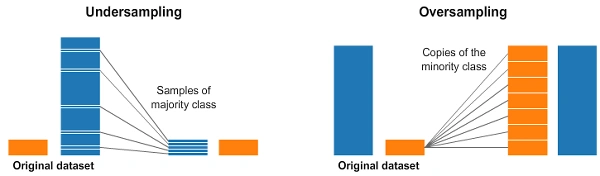

To further justify the use of SMOTE, the class distribution before and after resampling was visualised. This highlights the severity of the original class imbalance and demonstrates how SMOTE effectively balances the dataset without discarding majority-class samples.

**BEFORE**

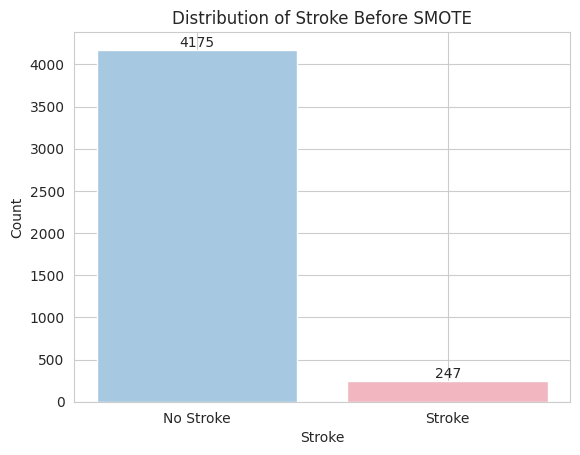

In [ ]:
# Count the number of people for each gender category
stroke = stroke_ds['stroke'].value_counts()

# Creating label for bar plot
x = ['No Stroke', 'Stroke']

# Create a bar plot
plt.bar(x, stroke.values, color = custom_palette)

# Add labels to the bars
for i, count in enumerate(stroke.values):
    plt.text(i, count, str(count), ha='center', va='bottom')

# Add labels and title
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Distribution of Stroke Before SMOTE')

# Show the plot
plt.show()

**AFTER**

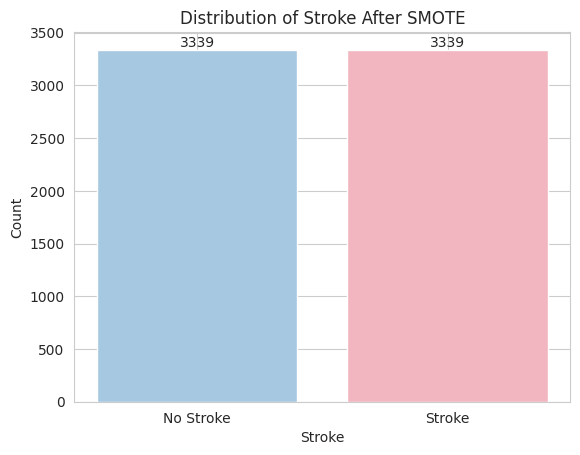

In [ ]:
# preprocess first
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

# Apply SMOTE on training data only
X_resampled, y_resampled = SMOTE(random_state=42).fit_resample(X_train_prep, y_train)

# Count the number of people for each stroke class AFTER SMOTE
stroke_after = pd.Series(y_resampled).value_counts()

# Creating label for bar plot
x = ['No Stroke', 'Stroke']

# Create a bar plot
plt.bar(x, stroke_after.values, color=custom_palette)

# Add labels to the bars
for i, count in enumerate(stroke_after.values):
    plt.text(i, count, str(count), ha='center', va='bottom')

# Add labels and title
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Distribution of Stroke After SMOTE')

# Show the plot
plt.show()

The visualization highlights the severe class imbalance in the original training data and demonstrates how SMOTE effectively balances the class distribution.


### **Overall Rationale**
Given the **severe class imbalance** in our stroke dataset, where the number of **stroke cases** is significantly lower, **SMOTE** is the most effective technique for balancing the class distribution. As it **generates synthetic samples** for the minority class, which helps the model better learn from the underrepresented class, while minimizing the risks of **overfitting** and **data loss** that can occur with **Random Oversampling** or **Random Undersampling**.

### **Final Steps for Pipeline**

In [ ]:
#Building the steps
steps = [
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),   # Handle class imbalance with SMOTE
    ("classifier", None)  # Placeholder for classifier, to be replaced dynamically
]

# **Modelling**
### **Model Selection**
Here are the models selected for stroke prediction and the reasons behind choosing them:

**Dummy Baseline**  
- Provides a **benchmark model** to ensure the classifier performs better than random chance.  
- The **stratified strategy** helps maintain the same class proportions in both the training and test sets, which is important for ensuring fair model evaluation in imbalanced datasets.


**Logistic Regression**  
- A **simple and interpretable model** that works well for **binary classification** tasks.  
- Helps understand the relationship between features like **age, hypertension, and glucose levels** and stroke risk. It’s also an **excellent baseline model** for comparison.


**Support Vector Machine (SVM)**  
- A **margin-based classifier** that handles both **linear and non-linear classification** effectively.  
- Known for **strong performance** in high-dimensional spaces and can capture **complex patterns**. SVM will be compared with Random Forest to see how a **non-tree-based model** approaches the task.


**Decision Tree**  
- A **single tree-based model** that splits the data into nodes based on feature values to make predictions.  
- **Easy to interpret**, as it visualizes the decision-making process through a tree structure.  
- **Prone to overfitting**, but can be controlled with pruning or limiting tree depth.  
- Provides **feature importance** to identify key predictors of stroke, which is useful for understanding the model's decision-making process.  
- Works well with both **numerical and categorical data**.


#### Why we use `random_state=42` in all models:
- **Reproducibility**: Setting `random_state=42` ensures that the **random splits** and **initializations** used in each model (e.g., for training/test split, Random Forest trees, or SVM optimization) are **consistent every time** you run the code. This allows us to get **identical results** each time, making debugging and model comparisons **fair** and **reliable**.

- **Consistency Across Models**: Using the same random seed (42 in this case) ensures that **all models** (DummyClassifier, Logistic Regression, SVM, Random Forest) are trained on the same data split and with the same randomization, allowing for **valid comparison** of their performances without external variability.

- **Why 42?**: The number 42 is **arbitrary** but **widely adopted** in the programming community as a **convention**. It’s just a random choice, but it is **familiar** and has **cultural significance** from *"The Hitchhiker's Guide to the Galaxy"* where it’s the “Answer to the Ultimate Question of Life, the Universe, and Everything.”


### **Overall Rationale**  
The chosen models provide a **diverse approach** to stroke prediction:
- **Logistic Regression** offers simplicity and interpretability.
- **Decision Tree** introduces more complexity, capable of capturing **non-linear relationships** and providing **feature importance**.
- **SVM** (Support Vector Machine) is effective for both **linear and non-linear classification**, especially in higher-dimensional spaces.
- **Dummy Baseline** ensures performance exceeds random chance, establishing a benchmark for model evaluation.

This approach allows for comprehensive **model comparison**, providing insights into the best-performing model for stroke prediction.



In [ ]:
# Placing the models into an array
clfs = [('Dummy Baseline', DummyClassifier(strategy="stratified", random_state=42)),
        ('Logistic Regression', LogisticRegression(random_state=42)),
        ('SVM', SVC(random_state=42, probability=True)),
        ('Decision Tree', DecisionTreeClassifier(random_state=42))]

### **Pipelining**

In [ ]:
# Initialize empty lists to store the heatmaps and ROC curve data
confusion_matrices = []
roc_data = []
roc_auc_scores = []

# For storing classification reports
classification_reports = {}

# Initialize empty dataframe to store evaluation metrics
scores_df = pd.DataFrame(columns=['Model', 'F1_Score', 'Precision', 'Recall','Specificity', 'Accuracy', 'Balanced_Accuracy', 'ROC_AUC'])

# Initialize list to store pipelines
pipelines = []

# Now evaluate models and store the results
for clf_name, clf in clfs:

    # Update the 'classifier' step with the current model
    steps[-1] = ('classifier', clf)    # model is always at the end so we can use -1

    # Create the pipeline
    pipeline = Pipeline(steps=steps)

     # Skip scaling only for Decision Tree
    if clf_name == 'Decision Tree':
        pipeline.set_params(preprocessing__numerical='passthrough')

    # Check the specific transformer assigned to the "numerical" key
    current_transformer = pipeline.get_params()['preprocessing__numerical']
    print(f"Model: {clf_name} | Transformer: {current_transformer}")

    # Fit the model and make predictions
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]  # Probabilities for ROC curve

    # Store the pipeline
    pipelines.append(pipeline)

    # Getting the results of each scoring
    new_row = {'Model': clf_name,
           'F1_Score': metrics.f1_score(y_test, y_pred, average='weighted'),
           'Precision': metrics.precision_score(y_test, y_pred, average='weighted'),
           'Recall': metrics.recall_score(y_test, y_pred, average='weighted'),
           'Specificity': metrics.recall_score(y_test, y_pred, pos_label=0),  # Specificity (True Negative Rate) -> Recall for class 0
           'Accuracy': metrics.accuracy_score(y_test, y_pred),
           'Balanced_Accuracy': metrics.balanced_accuracy_score(y_test, y_pred),  # Added Balanced Accuracy
           'ROC_AUC': metrics.roc_auc_score(y_test, y_prob)}  # ROC-AUC score

    scores_df = pd.concat([scores_df, pd.DataFrame([new_row])], ignore_index=True)

    # Confusion matrix and labels (for heatmap)
    cm = metrics.confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)  # Append confusion matrix to the list

    # ROC curve data (FPR, TPR, and AUC)
    fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
    roc_auc = metrics.auc(fpr, tpr)
    roc_data.append((fpr, tpr))  # Append FPR and TPR for ROC curve
    roc_auc_scores.append(roc_auc)  # Append AUC score for later use

    # Store the classification report
    classification_reports[clf_name] = metrics.classification_report(y_test, y_pred)

Model: Dummy Baseline | Transformer: StandardScaler()
Model: Logistic Regression | Transformer: StandardScaler()
Model: SVM | Transformer: StandardScaler()
Model: Decision Tree | Transformer: passthrough


Based on the output, we can see that **StandardScaler** was **not applied** to **Decision Trees** because they are not sensitive to feature scaling and make splits based on threshold values. Therefore, only the Dummy, Logistic Regression, and SVM models have scaling applied.

# **Evaluation Metrics for Stroke Prediction Model**

Before discussing the evaluation metrics, let's first define the key **classification outcomes**:

- **True Positive (TP)**: The model correctly predicts a **stroke** occurrence.
- **False Positive (FP)**: The model incorrectly predicts **stroke**, but the patient did not have a stroke (Type I Error).
- **True Negative (TN)**: The model correctly predicts **no stroke**.
- **False Negative (FN)**: The model incorrectly predicts **no stroke**, but the patient actually had a stroke (Type II Error).

For this project, several evaluation metrics are selected, which are especially relevant for imbalanced datasets like stroke prediction:


#### **1. F1 Score**

- **Formula**:
$$
F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$
- **Why**: The **F1 score** balances **precision** and **recall**, which is essential for stroke prediction where both **false positives** (healthy people wrongly identified as at risk) and **false negatives** (missed stroke cases) are important to minimize.

#### **2. Precision**
- **Formula**:
$$
\text{Precision} = \frac{TP}{TP + FP}
$$
- **Why**: **Precision** helps us understand the accuracy of predicted stroke cases. A high **precision** means fewer **False Positives**, meaning the model is good at identifying true stroke cases and avoiding unnecessary alarm.

#### **3. Recall (True Positive Rate)**

- **Formula**:
$$
\text{Recall} = \frac{TP}{TP + FN}
$$
- **Why**: **Recall** measures the percentage of actual stroke cases that the model correctly identifies. It is **critical** in medical applications where **False Negatives** (missing potential stroke cases) have serious consequences.

#### **4. Specificity (True Negative Rate)**

- **Formula**:
$$
\text{Specificity} = \frac{TN}{TN + FP}
$$
- **Why**: **Specificity** measures the model's ability to correctly identify healthy individuals (non-stroke cases). It’s important for reducing **False Positives** and ensuring healthy individuals aren't misclassified as high-risk for a stroke.


#### **5. Accuracy**
- **Formula**:
$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$
- **Why**: While **accuracy** can be misleading for imbalanced datasets, it still provides an overall picture of how many predictions were correct. However, it's **less useful** when the dataset is **heavily imbalanced** (e.g., more non-stroke cases than stroke cases).


#### **6. Balanced Accuracy**

- **Formula**:
$$
\text{Balanced Accuracy} = \frac{TPR + TNR}{2}
$$
- **Why**: **Balanced Accuracy** ensures that both the **True Positive Rate (Recall)** and **True Negative Rate (Specificity)** are equally considered. It is especially useful for imbalanced datasets as it doesn't bias towards the majority class.

#### **7. ROC-AUC (Receiver Operating Characteristic - Area Under the Curve)**

- **Why**: **ROC-AUC** provides a summary of the model's performance across all classification thresholds, making it ideal for evaluating **imbalanced datasets** like stroke prediction. The **higher the AUC**, the better the model can distinguish between stroke and no-stroke cases.


These evaluation metrics are designed to assess the model's ability to correctly predict stroke outcomes, particularly in datasets where classes (stroke vs. no-stroke) are imbalanced. **F1 Score**, **Recall**, **Precision**, and **Balanced Accuracy** are critical for evaluating the model's performance in such cases, while **Specificity** and **ROC-AUC** help understand the model's discrimination ability.

---

#### **Why Use `average='weighted'` for F1-Score, Precision, and Recall, but Not for Accuracy and Specificity?**

In the context of our imbalanced stroke prediction dataset, where the number of **stroke cases** ("Stroke") is much smaller than the **non-stroke cases** ("No Stroke"), using `average='weighted'` for **F1-Score**, **Precision**, and **Recall** ensures that these metrics properly account for the class imbalance:

- **F1-Score**, **Precision**, and **Recall** are sensitive to **class imbalance**, and **`average='weighted'`** helps adjust for class frequencies, ensuring that both the **majority** and **minority classes** are considered fairly. This provides a more **balanced evaluation** of the model's performance across both classes.
  
For **Accuracy** and **Specificity**, however, **`average='weighted'`** is unnecessary because:
- **Accuracy** is dominated by the **majority class** and doesn't give a good representation of the model's ability to predict the minority class in imbalanced datasets.
- **Specificity** reflects how well the model identifies **non-stroke cases** and doesn't require weighting since it focuses on the majority class.

---

#### **Conclusion**:
- **For F1-Score**, **Precision**, and **Recall**, **`average='weighted'`** helps to account for class imbalance and provides a more accurate reflection of the model's performance on both classes.
- **Accuracy** and **Specificity** don't need the weighted average, as they either give an overall performance view or focus on the majority class.

### **Baseline Results Before SMOTE**
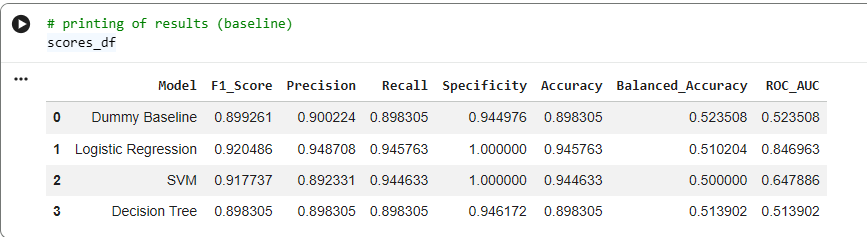

**Observations (Before SMOTE)**

- **Dummy Baseline**:    Achieves a high **F1-Score** of **~0.90** and **accuracy** of **~0.90**, but this performance is **misleading** due to severe class imbalance. The **balanced accuracy** of **~0.52** and **ROC AUC** of **~0.52** indicate performance close to **random guessing**, showing that the model primarily predicts the **majority (non-stroke) class** and fails to meaningfully identify stroke cases.

- **Logistic Regression**:   Shows strong overall performance with a **F1-Score** of **~0.92**, high **precision**, **recall**, and **accuracy** of **~0.95**. However, the **balanced accuracy** of **~0.51** suggests that this performance is driven largely by correct predictions of the **majority class**. Despite this, the high **ROC AUC** of **~0.85** indicates good **underlying class separability** that is not fully realised due to class imbalance.

- **SVM**:
  Achieves a high **F1-Score** of **~0.92** and **accuracy** of **~0.94**, but the **balanced accuracy** of **~0.50** reveals poor performance across both classes. The lower **ROC AUC** of **~0.65**, compared to **Logistic Regression**, suggests weaker discrimination between stroke and non-stroke cases before resampling.

- **Decision Tree**: Displays high **accuracy** and **F1-Score** of **~0.90**, but its **balanced accuracy** of **~0.51** and **ROC AUC** of **~0.51** indicate limited ability to distinguish between classes. This suggests a strong bias toward the **majority class**, with poor effectiveness in capturing stroke cases under the imbalanced dataset.

**Key Takeaways**
- High **accuracy** and **weighted F1-Scores** are **misleading** indicators of performance under severe class imbalance.
- All models exhibit **balanced accuracy close to random guessing**, indicating poor detection of the **minority (stroke) class**.
- **Logistic Regression** demonstrates the strongest **underlying class separability** prior to resampling, as reflected by its higher **ROC AUC**.
- These results clearly motivate the use of **SMOTE** to reduce majority-class bias and enable more meaningful evaluation of stroke prediction models.


### **Baseline Results After SMOTE**


In [ ]:
# printing of results (SMOTE)
scores_df

,Model,F1_Score,Precision,Recall,Specificity,Accuracy,Balanced_Accuracy,ROC_AUC
0,Dummy Baseline,0.623165,0.892335,0.499435,0.501196,0.499435,0.485292,0.485292
1,Logistic Regression,0.824011,0.935783,0.760452,0.760766,0.760452,0.757934,0.836954
2,SVM,0.865433,0.919707,0.827119,0.848086,0.827119,0.658737,0.775754
3,Decision Tree,0.899913,0.900392,0.899435,0.946172,0.899435,0.524107,0.524107


**Observations**
- **Dummy Baseline**: Performs poorly with a **F1-Score** of **0.62**, primarily due to **low recall** for the minority class. It's mainly predicting the **majority class**, leading to a **balanced accuracy** close to random guessing (**0.50**). The **Specificity** is also 0.50, indicating that the model is not significantly better than random in predicting the negative class.

- **Logistic Regression**: Shows significant improvement with a **F1-Score** of **0.82** and good balance between **Precision** and **Recall**. The **ROC AUC** of **0.84** indicates better performance in distinguishing between classes. The **Specificity** of 0.76 demonstrates the model's ability to correctly predict the negative class, and the **balanced accuracy** of 0.76 confirms a good balance in its overa

- **SVM**: Achieves the highest **F1-Score** of **0.87** and also demonstrates strong **Recall** for the minority class (**0.83**). **ROC AUC** of **0.78** is solid, though slightly behind **Logistic Regression**. The **Specificity** is 0.85, indicating that it is good at identifying the negative class as well. However, its **Balanced Accuracy** of 0.66 suggests that SVM might be somewhat unbalanced in favor of the majority class.

- **Decision Tree**: Performs well on **precision** (**0.90**) and **recall** (**0.90**), but its **balanced accuracy** is lower (**0.52**), indicating potential bias toward the majority class despite high performance in the metrics. Despite **high Specificity (0.95)**, the model's ability to correctly predict the negative class, it struggles to balance its performance across both classes, leading to a **much lower Balanced Accuracy**.

**Key Takeaways**
- **Logistic Regression** and **SVM** are the strongest models, with **SVM** slightly outperforming in **F1-Score**, while **Logistic Regression** leads in **ROC AUC**.
- **Decision Tree** offers good precision and recall but struggles with **balanced accuracy** (0.52) and **ROC AUC** (0.52), indicating a bias toward the majority class despite performing well in some metrics. The high **Specificity** suggests it is good at predicting the negative class but struggles with the positive class.
- **Dummy Baseline** is far behind, with **balanced accuracy** and **specificity** close to random guessing (0.50).




### **Overall Comparison (Before vs After SMOTE)**
- **Before SMOTE**, most models achieved **high accuracy** and **high weighted F1-Scores**, but these results were **misleading** due to severe class imbalance. **Balanced accuracy** values close to **0.50** and low **ROC AUC** (except for **Logistic Regression**) indicate that models were largely biased toward predicting the **majority (non-stroke) class**.

- **After SMOTE**, there is a clear improvement in **balanced accuracy** and a more meaningful trade-off between **Recall** and **Specificity**, showing that models are better able to learn patterns from **both classes** rather than defaulting to the majority class.

- **Logistic Regression** shows the most **consistent performance** across both settings, maintaining a strong **ROC AUC** while achieving a substantially higher **balanced accuracy** after SMOTE. This suggests good **generalisation** once class imbalance is addressed.

- **SVM** benefits noticeably from SMOTE, achieving the **highest F1-Score** after resampling and improved detection of stroke cases, although its **balanced accuracy** remains slightly lower than Logistic Regression, indicating some residual class imbalance effects.

- **Decision Tree** shows limited improvement after SMOTE. Despite strong **precision** and **recall** in aggregate metrics, its consistently low **balanced accuracy** and **ROC AUC** suggest poor class separability and potential **overfitting**, making it less suitable for this task.

- Overall, **SMOTE is justified** as it reduces majority-class bias and leads to more **clinically meaningful evaluation**, where identifying stroke cases is prioritised over maximising raw accuracy.


### **Next Steps:**
- Further evaluation using **confusion matrix**, **classification reports**, and **ROC curves** will help visualize and confirm the model performance across metrics.

### **Confusion Matrix**
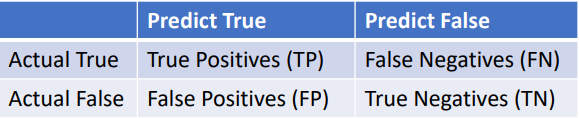


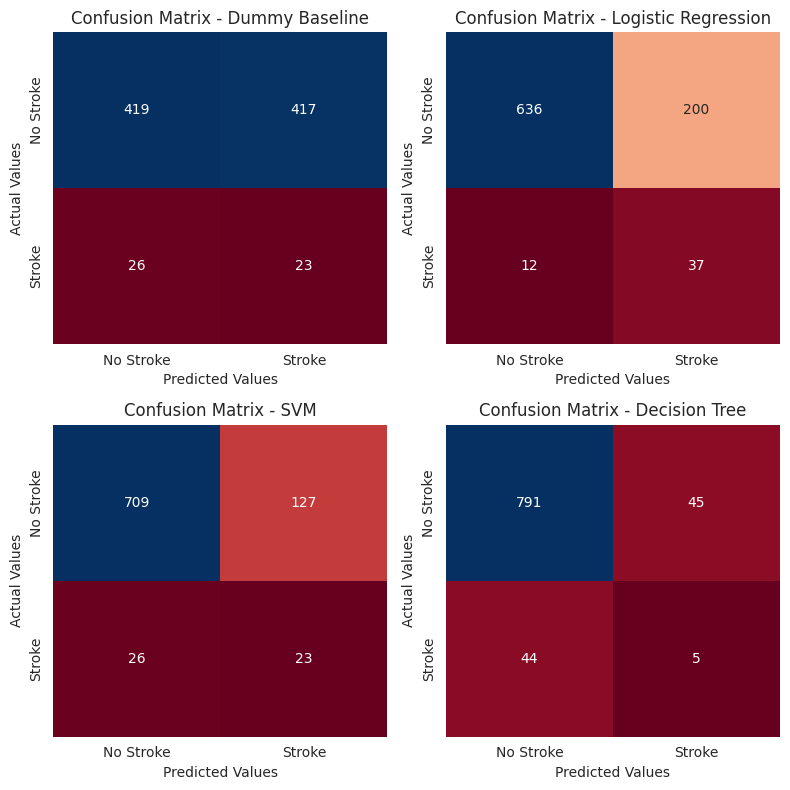

In [ ]:
# Now plot all confusion matrix as heatmaps
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.ravel()  # Flatten axes for easier indexing

for i, cm in enumerate(confusion_matrices):
    # Plot the heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdBu', ax=axes[i], cbar=False,
                xticklabels=['No Stroke', 'Stroke'],  # Modify these labels
                yticklabels=['No Stroke', 'Stroke'])  # Modify these labels

    axes[i].set_title(f'Confusion Matrix - {clfs[i][0]}')
    axes[i].set_ylabel("Actual Values")
    axes[i].set_xlabel("Predicted Values")

plt.tight_layout()
plt.show()

**Insights**
1. **Dummy Baseline Model**:
   - The **Dummy Baseline** has high **false positives (417)** and **false negatives (26)**, indicating poor performance in predicting both stroke and no stroke outcomes. This model simply predicts the majority class, showing that it doesn't contribute useful predictive power.

2. **Logistic Regression**:
   - **False Positives**: There are **200 false positives** (predicted "stroke" but actual "no stroke"), showing a tendency to over-predict stroke cases.
   - **True Positives**: There are **37 true positives** (correctly predicted stroke), which is relatively low, suggesting that **Logistic Regression** might need further tuning or more features to improve stroke prediction accuracy.
   - While better than the Dummy Baseline, **Logistic Regression** still struggles with false positives and low true positives, indicating that further improvements are needed to make it more effective at stroke prediction.

3. **Support Vector Machine (SVM)**:
   - **High True Negatives**: With **709 true negatives** (correctly predicting no stroke), SVM shows strong performance on this class.
   - **False Positives**: There are **127 false positives**, showing some tendency to misclassify no-stroke cases as stroke.
   - **True Positives and False Negatives**: SVM performs similarly to **Logistic Regression**, with **23 true positive**s and **26 false negatives**. However, it still underperforms in predicting stroke cases, suggesting room for improvement.

4. **Decision Tree**:
   - **Strong Bias Towards "No Stroke"**: The Decision Tree model shows a strong bias towards predicting "No Stroke" (with **791 true negatives**), but it **underperforms significantly** in predicting stroke cases, with only **5 true positives** and **44 false negatives**.
   - **Key Insight**: The **Decision Tree** is heavily skewed toward "No Stroke" predictions, leading to high **true negatives** but very low **true positives**. This makes it **not the most effective model for stroke prediction** compared to others like **Logistic Regression** and **SVM**, which have **better stroke prediction accuracy**.

**Key Takeaways**
- **Best Model**: **Logistic Regression** provides the best balance between **sensitivity** (true positives) and **specificity** (true negatives) for predicting strokes. However, further tuning or additional features are needed to improve its prediction accuracy.

- **Worst Model**: The **Dummy Baseline** is the least effective model, offering no meaningful predictive power.

- **Model Comparison**: **Decision Tree** has the highest true negatives but is heavily biased towards "No Stroke" predictions, leading to very poor stroke prediction (low true positives). **Logistic Regression** and **SVM** provide better stroke prediction performance but still need improvements.

- **Actionable Insights**: The **Decision Tree** model needs to be adjusted to balance the prediction of both classes. **Logistic Regression** and **SVM** can be improved with more features or better tuning to reduce false positives and increase true positives.

### **Classification Reports**

In [ ]:
# Print out the classification reports after all evaluations
for clf_name, report in classification_reports.items():
    print(f"Classification Report for {clf_name}:\n")
    print(report)

Classification Report for Dummy Baseline:

              precision    recall  f1-score   support

           0       0.94      0.50      0.65       836
           1       0.05      0.47      0.09        49

    accuracy                           0.50       885
   macro avg       0.50      0.49      0.37       885
weighted avg       0.89      0.50      0.62       885

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       0.98      0.76      0.86       836
           1       0.16      0.76      0.26        49

    accuracy                           0.76       885
   macro avg       0.57      0.76      0.56       885
weighted avg       0.94      0.76      0.82       885

Classification Report for SVM:

              precision    recall  f1-score   support

           0       0.96      0.85      0.90       836
           1       0.15      0.47      0.23        49

    accuracy                           0.83       885
   ma

**Insights from Classification Reports**
1. **Dummy Baseline**:
   - **Accuracy**: 50%, indicating the model is just predicting the majority class ("No Stroke").
   - **Precision for "Stroke"**: Very low (0.05), meaning most of its "stroke" predictions are wrong.
   - **Recall for "Stroke"**: 0.47, suggesting it misses more than half of the actual stroke cases.

2. **Logistic Regression**:
   - **Accuracy**: 76%, better than Dummy Baseline.
   - **Precision for "Stroke"**: 0.16, still low, meaning many predicted strokes are incorrect.
   - **Recall for "Stroke"**: 0.76, which is good, indicating it correctly identifies most stroke cases but with many false positives.

3. **SVM**:
   - **Accuracy**: 83%, a strong overall performance.
   - **Precision for "Stroke"**: 0.15, indicating many false positives for stroke.
   - **Recall for "Stroke"**: 0.47, similar to Logistic Regression, but still misses many strokes.

4. **Decision Tree**:
   - **Accuracy**: 90%, but biased towards "No Stroke" predictions.
   - **Precision for "Stroke"**: 0.10, which is very low, showing it struggles with predicting stroke.
   - **Recall for "Stroke"**: 0.10, meaning it fails to identify most stroke cases.


**Key Takeaways**
- **Best Model**: **Logistic Regression** performs the best for stroke detection with a recall of 0.76, but its precision is low. It needs improvement to reduce false positives.
- **Worst Model for Stroke**: **Decision Tree** shows high accuracy overall but underperforms in predicting strokes, with low recall (0.10).
- **Best for "No Stroke"**: All models, especially **SVM** and **Decision Tree**, perform well at predicting "No Stroke" cases.

### **Visualising ROC curves**

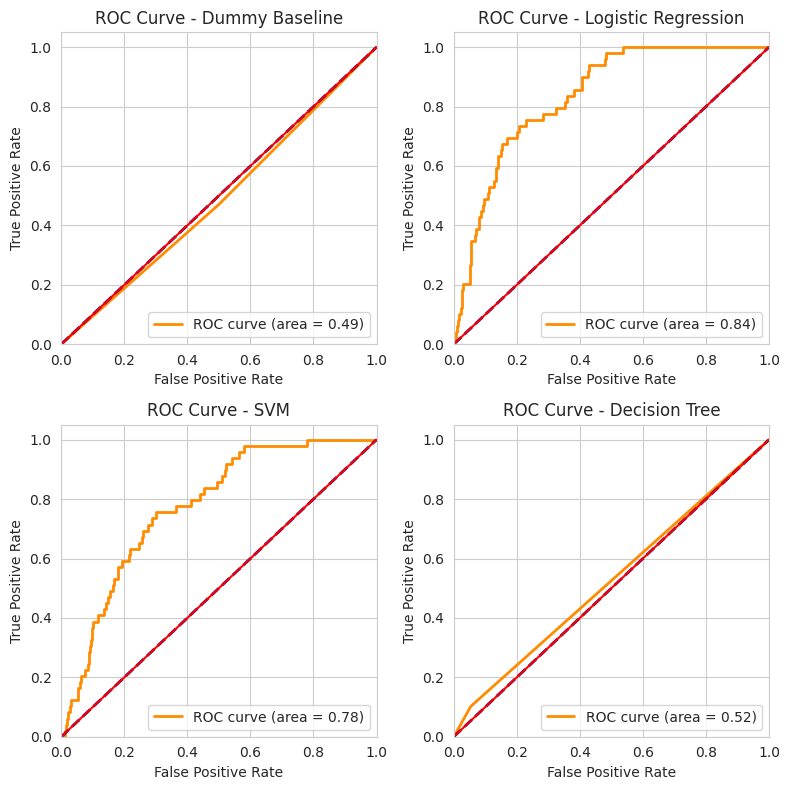

In [ ]:
# Now plot all ROC curves
fig_roc, axes_roc = plt.subplots(2, 2, figsize=(8, 8))
axes_roc = axes_roc.ravel()  # Flatten axes for easier indexing

for i, (fpr, tpr) in enumerate(roc_data):
    ax = axes_roc[i]
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_scores[i]:.2f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve - {clfs[i][0]}')
    ax.legend(loc="lower right")

# 50% line (red diagonal)
for ax in axes_roc:
    x = np.linspace(0, 1, 2)
    ax.plot(x, x, color="red")

plt.tight_layout()
plt.show()

**Insights from ROC Curves**
1. **Dummy Baseline**:
   - **AUC (Area Under the Curve)**: **0.49**, which is close to 0.5. This indicates that the model is performing nearly as bad as random guessing. It is not able to distinguish between the classes effectively.
   - **Interpretation**: The ROC curve is very close to the diagonal, meaning the model has poor performance and no real predictive power.

2. **Logistic Regression**:
   - **AUC**: **0.84**, indicating a **strong model** with good discriminatory power. The curve is closer to the top-left corner, suggesting it correctly distinguishes between classes (stroke vs no stroke) with high accuracy.
   - **Interpretation**: Logistic Regression shows significant improvement over the Dummy Baseline, with the curve approaching the optimal 90-degree corner, indicating good predictive capability.

3. **SVM**:
   - **AUC**: **0.78**, which is decent but not as high as Logistic Regression. The ROC curve indicates **moderate performance**, with some ability to distinguish between classes, though not as well as Logistic Regression.
   - **Interpretation**: SVM performs better than the Dummy Baseline but could still be improved, as it doesn’t reach the optimal curve of Logistic Regression.

4. **Decision Tree**:
   - **AUC**: **0.52**, indicating **slightly better than random guessing**. The curve is very close to the diagonal, suggesting the model is struggling to correctly identify stroke vs no stroke.
   - **Interpretation**: The Decision Tree is not very effective for this dataset, as its ROC curve does not significantly outperform random guessing.

**Key Takeaways**
- **Best Model**: **Logistic Regression** with an AUC of **0.84** has the best performance in distinguishing between stroke and no-stroke cases.
- **Worst Model**: **Dummy Baseline** with an AUC of **0.49** performs nearly as badly as random guessing.
- **Improvement Areas**: **SVM** and **Decision Tree** can benefit from further tuning to improve their performance, as their AUCs (0.78 and 0.52) suggest moderate to poor predictive ability.


# **Conclusion**

For **imbalanced datasets** like stroke prediction:
- **F1 score**, **recall**, and **precision** are **prioritized** as they help us understand how well the model is identifying true stroke cases and minimizing both false positives and false negatives.
- **ROC-AUC** is used to assess the model's overall **discriminatory ability** across different thresholds.
- **Specificity** and **Balanced Accuracy** are key metrics in imbalanced settings:
  - **Specificity** measures the model's ability to correctly identify negative cases (no stroke), which is critical in understanding how well the model avoids false positives.

  - **Balanced Accuracy** averages **recall** (sensitivity) and **specificity**, ensuring that both classes are treated fairly.
- **Accuracy** is included but given **less weight** due to the potential for misleading results in imbalanced datasets.


This set of evaluation metrics is aligned with the **CRISP-DM methodology** by focusing on **fair, balanced model evaluation**, ensuring that we prioritize **correct predictions** while avoiding over-optimizing performance at this stage.

Based on the results from various evaluations, **Logistic Regression** has emerged as the most effective model for stroke prediction, outperforming others in key metrics such as **ROC AUC** and **recall** for stroke detection. However, **SVM** and **Decision Tree** models also showed promising results, with **SVM** slightly outperforming in **F1-Score**, while **Decision Tree** excelled in **precision** and **recall** for "No Stroke".

Despite the good performance of **Logistic Regression**, further improvements are needed. Specifically, additional tuning through **hyperparameter optimization** (e.g., grid search) and the **use of ensemble methods** (like gradient boosting, random forest, etc) could significantly improve prediction accuracy, particularly for stroke detection.

#### **Link Back to Problem Statement:**
The **goal** of this project is to provide individuals like **Bob**, a 45-year-old office worker with hypertension, insights into their **stroke** risk based on health data. By accurately predicting the likelihood of stroke, this model will allow people to make informed decisions about seeking medical advice and taking preventive measures.

In Stage 1, the **Logistic Regression** model has been found to be the most effective, but further improvement in prediction accuracy will help provide more reliable insights to individuals at risk, like Bob, in making their healthcare decisions

#### **Next Steps:**
1. Stage 2 - Hyperparameter Tuning
    - Implement **hyperparameter tuning** using techniques like grid search and randomized search to optimize the models' performance.

    - Apply **ensemble methods** like **Gradient Boosting** and **Random Forest** to enhance the overall model's performance, especially for stroke detection.

2. Feature Engineering:
    - While **Stage 1** focuses on data understanding and baseline modeling, **feature importance** will be used in **Stage 2** to refine the feature set and guide future model improvements. This will help in enhancing the predictive power of the models, especially in preparation for **hyperparameter tuning** and more complex models.

3. Model Comparison & Evaluation:
    - After tuning, evaluate models with the same metrics used in Stage 1 and compare the results to ensure progress and effectiveness.

4. Cross-Validation:
    - **Cross-validation** will be implemented in **Stage 2** to better assess model stability and performance across multiple data splits. This will provide a more robust estimate of how well the models generalize to unseen data and help in comparing model performance in a more reliable way.

#### **Limitations:**
- **Model Interpretability:** While **Logistic Regression** provides a solid foundation, more complex models like **SVM** or **Decision Tree** could be difficult to interpret in a healthcare context. Further work on **model explainability** might be useful.
- **Class imbalance handling:** While SMOTE was applied in Stage 1 to address data imbalance, algorithm-level approaches such as **class weighting** will be explored in Stage 2 to further improve **minority-class (stroke) recall** without increasing overfitting risk.

#### **Overall Rational**
In conclusion, **Logistic Regression** is currently the best-performing model but is **subject to changes** after the planned **hyperparameter tuning** and **ensemble methods** in **Stage 2**. These improvements, along with the consideration of **feature importance**, will likely lead to better and more reliable predictions in the final model, ultimately providing **Bob** and others at risk with clearer insights into their stroke risk.

# **References and Resources**

1. **Pros and Cons between `pd.get_dummies` and `OneHotEncoder` (sklearn)**  
   [Stack Overflow - pd.get_dummies vs OneHotEncoder](https://stackoverflow.com/questions/36631163/what-are-the-pros-and-cons-between-get-dummies-pandas-and-onehotencoder-sciki)

2. **SVM `predict_proba` Function**  
   [GeeksforGeeks - Understanding `predict_proba` function in SVC](https://www.geeksforgeeks.org/machine-learning/understanding-the-predictproba-function-in-scikit-learns-svc/)

3. **Using `pipeline.set_params(preprocessing__numerical='passthrough')`**  
   [Towards Data Science - Getting the most out of scikit-learn pipelines](https://towardsdatascience.com/getting-the-most-out-of-scikit-learn-pipelines-c2afc4410f1a/)

4. **Imbalanced Datasets - Random Sampling and Over Sampling**  
   [Machine Learning Mastery - Random Oversampling and Undersampling](https://machinelearningmastery.com/random-oversampling-and-undersampling-for-imbalanced-classification/)  
   [Machine Learning Mastery - Navigating Imbalanced Datasets with Pandas and Scikit-Learn](https://machinelearningmastery.com/navigating-imbalanced-datasets-with-pandas-and-scikit-learn/)

5. **Imbalanced Datasets - SMOTE**  
   [Machine Learning Mastery - SMOTE for Imbalanced Classification](https://machinelearningmastery.com/smote-oversampling-for-imbalanced-classification/)  
   [GeeksforGeeks - SMOTE for Imbalanced Classification with Python](https://www.geeksforgeeks.org/machine-learning/smote-for-imbalanced-classification-with-python/)  
   [imbalanced-learn - SMOTE Documentation](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html)

6. **Techniques to Deal with Imbalanced Datasets**  
   [Analytics Vidhya - Techniques to Deal with Class Imbalance](https://www.analyticsvidhya.com/blog/2020/07/10-techniques-to-deal-with-class-imbalance-in-machine-learning/#The_Problem_With_Class_Imbalance_in_Machine_Learning)  
   [Machine Learning Mastery - 5 Effective Ways to Handle Imbalanced Data](https://machinelearningmastery.com/5-effective-ways-to-handle-imbalanced-data-in-machine-learning/)

7. **Tips for Effectively Training Machine Learning Models**  
   [Machine Learning Mastery - Tips for Effective Model Training](https://machinelearningmastery.com/tips-for-effectively-training-your-machine-learning-models/)

8. **Diagnosing Why Your Classification Model Fails**  
   [Machine Learning Mastery - How to Diagnose Why Your Classification Model Fails](https://machinelearningmastery.com/how-to-diagnose-why-your-classification-model-fails/)

9. **Confusion Matrix**  
   [GeeksforGeeks - Confusion Matrix in Machine Learning](https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/)  
   [W3Schools - Python ML Confusion Matrix](https://www.w3schools.com/python/python_ml_confusion_matrix.asp)

10. **Evaluation Metrics for Imbalanced Classification**  
    [Machine Learning Mastery - Evaluation Metrics for Imbalanced Classification](https://machinelearningmastery.com/tour-of-evaluation-metrics-for-imbalanced-classification/)

11. **Macro vs. Weighted Average**  
    [GeeksforGeeks - Macro Average vs Weighted Average](https://www.geeksforgeeks.org/machine-learning/macro-average-vs-weighted-average/)

12. **Background Research on Stroke**  
    [HealthHub Singapore – Stroke: About Stroke](https://www.healthhub.sg/health-conditions/stroke-about-stroke)  
    [HealthHub Singapore – Stroke: Types of Stroke](https://www.healthhub.sg/health-conditions/stroke-types-of-stroke)  
    [Great Eastern – Being Mindful of Stroke](https://www.greateasternlife.com/sg/en/personal-insurance/lifepedia/medical-coverage/hospitalisation/being-mindful-of-stroke.html)

13. **Heatmap Visualisations**  
    [GeeksforGeeks - Pandas .crosstab() function in Python](https://www.geeksforgeeks.org/python/pandas-crosstab-function-in-python/)  
    [GeeksforGeeks - Create a Correlation Matrix using Python](https://www.geeksforgeeks.org/data-science/create-a-correlation-matrix-using-python/)
    

14. **Reference to Top Kaggle Notebooks (Most Voted, Ranked 1-3)**  
   [Predicting a Stroke - SHAP, LIME, ELI5](https://www.kaggle.com/code/joshuaswords/predicting-a-stroke-shap-lime-explainer-eli5)  
   [Data Storytelling: AUC Focus on Strokes](https://www.kaggle.com/code/bhuvanchennoju/data-storytelling-auc-focus-on-strokes)  
   [How to Make Clean Visualizations](https://www.kaggle.com/code/gaetanlopez/how-to-make-clean-visualizations)